# E6: Anchoring methods (simulated data)

**Started:** January 21, 2026

**Last updated:** January 21, 2026

**Research question:** Can fused Gromov OT and seeded GOT (non-random transport plan initialization)prevent the symmetry mismatch failure mode? 

**Hypothesis:** Both methods will be able to prevent the symmetry mismatch, with fused Gromov OT being superior because it biases the objective function to prevent symmetry mismatch. 

**Conclusion:** Seeded GOT results in invidiual point pairing, but ideally have one anchor per population. FGW only results in individual point pairing, not symmetric alignment.

**Potential Next Steps:** Explore subpopulation alignment when subpopulations segregate in only some dimensions.

In [3]:
# make sure we are in the correct directory
%cd /n/holylabs/mooney_lab/Lab/joshprice/speciesOT

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT


In [313]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import ot
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from speciesot_simulation_helpers import generate_point_clouds, \
                              plot_first_two_dims, \
                              resample_point_clouds, \
                              flatten_clouds, \
                              run_ot, \
                              compute_mapping_acc, \
                              knn_geodesic_distance_matrix, \
                              plot_knn_graph, \
                              plot_got_best_matches_with_labels
import speciesot_simulation_helpers

In [42]:
clouds1, means1, covs1 = generate_point_clouds(4, 20, 2, A=2, B=0.5)
cloud_coords1, labels1 = flatten_clouds(clouds1)
clouds2 = resample_point_clouds(means1, covs1, 20)
cloud_coords2, labels2 = flatten_clouds(clouds2)

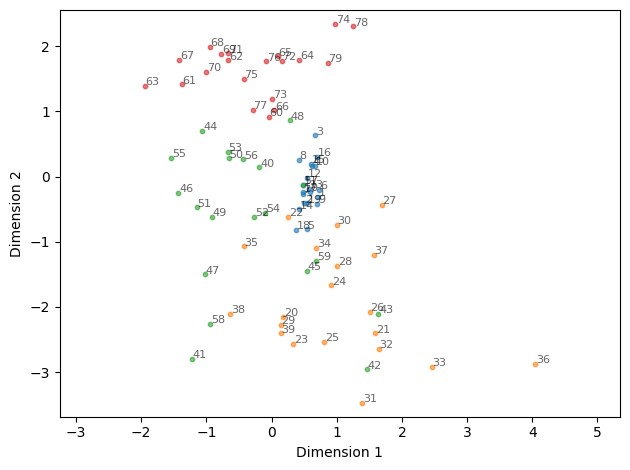

In [43]:
plot_first_two_dims(clouds1, annotate=True)

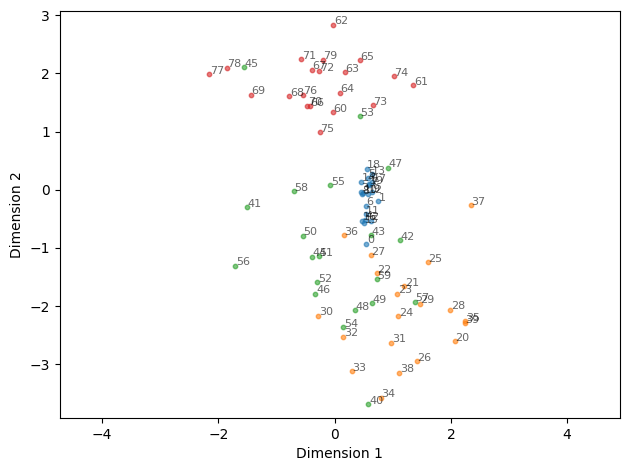

In [44]:
plot_first_two_dims(clouds2, annotate=True)

In [45]:
gw_unanchored = run_ot(cloud_coords1, cloud_coords2, 80)

Text(0.5, 1.0, 'GOT source and target pairings without anchor')

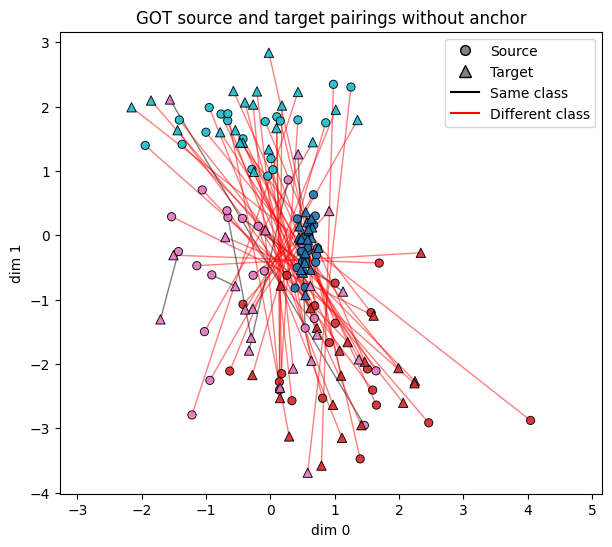

In [46]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gw_unanchored, labels1, labels2)
plt.title("GOT source and target pairings without anchor")

In [58]:
cloud_coords1.shape

(80, 2)

In [59]:
cloud_coords2.shape

(80, 2)

In [100]:
import numpy as np
import ot  # POT

def fgw_with_label_anchors(
    xs, xt, src_anchors, tgt_anchors,
    alpha=0.2, mismatch_cost=10.0,
    p=None, q=None, distance_method="euclidean",
    epsilon=0.1
):
    """
    X1: (n1,d1) coords/features for source points
    X2: (n2,d2) coords/features for target points
    Uses:
      - C1, C2 = intra-space distance matrices computed from X1, X2
    """
    
    assert len(src_anchors) == len(tgt_anchors), "Anchor lists must have same length"

    n1, n2 = xs.shape[0], xt.shape[0]
    
    p = np.ones(n1) / n1 if p is None else np.asarray(p, float).ravel()
    q = np.ones(n2) / n2 if q is None else np.asarray(q, float).ravel()

    # Intra-space distances (what GW/FGW needs)
    if distance_method == "geodesic":
        C1 = knn_geodesic_distance_matrix(xs, k=knn_k, visualize=visualize)
        C2 = knn_geodesic_distance_matrix(xt, k=knn_k, visualize=visualize)
    else:
        C1 = sp.spatial.distance.cdist(xs, xs)
        C2 = sp.spatial.distance.cdist(xt, xt)

    # Anchor-label features (secondary info -> M)
    y1 = np.zeros(n1, dtype=int)
    y2 = np.zeros(n2, dtype=int)
    for k, (i, j) in enumerate(zip(src_anchors, tgt_anchors), start=1):
        y1[i] = k
        y2[j] = k

    # Feature cost matrix: 0 if same label, mismatch_cost otherwise
    M = (y1[:, None] != y2[None, :]).astype(float) * mismatch_cost

    # FGW solve
    pi = ot.gromov.fused_gromov_wasserstein(
        M, C1, C2, loss_fun="square_loss", alpha=alpha
    )
    
    #gw, log = ot.gromov.entropic_gromov_wasserstein(
    #    C1, C2, p, q, "square_loss", epsilon=epsilon, solver="PPA", log=True)
    return pi

In [123]:
fgw_anchored = fgw_with_label_anchors(cloud_coords1, cloud_coords2, [63,31,27], [77,34,37], alpha=0.1)

In [124]:
fgw_anchored

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(80, 80))

Text(0.5, 1.0, 'GOT source and target pairings with anchor')

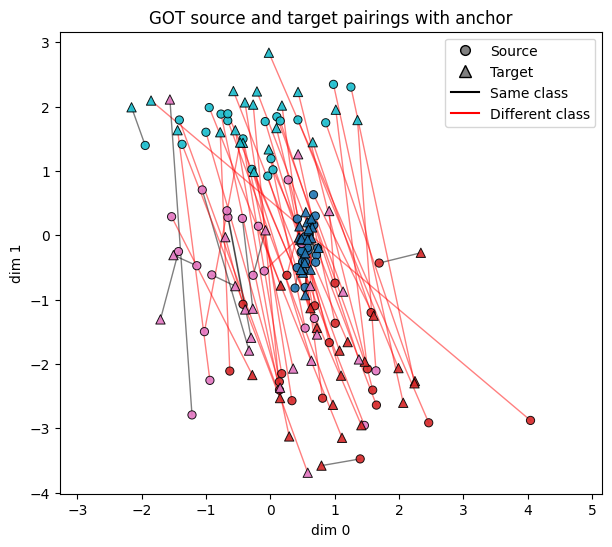

In [125]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, fgw_anchored, labels1, labels2)
plt.title("GOT source and target pairings with FGW anchors")

### Outlier-forced anchoring (custom)

In [126]:
def run_ot_with_anchor(xs, xt, n_samples, anchor_xs, anchor_xt, epsilon=0.1, distance_method="euclidean", knn_k = 3, visualize=False):
    # anchor_xs is the index of the anchor in xs
    # anchor_ys is the index of the anchor in ys
    if distance_method == "geodesic":
        C1 = knn_geodesic_distance_matrix(xs, k=knn_k, visualize=visualize)
        C2 = knn_geodesic_distance_matrix(xt, k=knn_k, visualize=visualize)
    else:
        C1 = sp.spatial.distance.cdist(xs, xs)
        C2 = sp.spatial.distance.cdist(xt, xt)

    C1 /= C1.max()
    C2 /= C2.max()
    
    anchor_mult = 10
    
    C1[anchor_xs, :] += anchor_mult  # 10 times the maximum distance
    C1[:, anchor_xs] += anchor_mult
    C1[anchor_xs, anchor_xs] -= 2 * anchor_mult  # leave distance to self unchanged
    
    C2[anchor_xt, :] += anchor_mult  # 10 times the maximum distance
    C2[:, anchor_xt] += anchor_mult
    C2[anchor_xt, anchor_xt] -= 2 * anchor_mult  # leave distance to self unchanged

    p = ot.unif(n_samples)
    q = ot.unif(n_samples)

    # Proximal Point algorithm with Kullback-Leibler as proximal operator
    gw, log = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=epsilon, solver="PPA", log=True)
    
    return gw

In [127]:
gw_anchored = run_ot_with_anchor(cloud_coords1, cloud_coords2, 80, 63, 77)

Text(0.5, 1.0, 'GOT source and target pairings with outlier-based anchor')

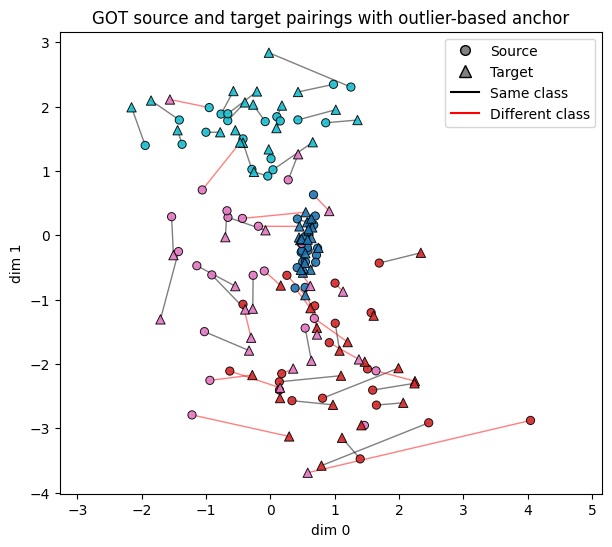

In [128]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gw_anchored, labels1, labels2)
plt.title("GOT source and target pairings with outlier-based anchor")

### Seeded OT

In [191]:
def make_seeded_G0(p, q, src_anchors, tgt_anchors, boost=50.0, n_ipfp=200, eps=1e-12):
    """
    Build an initial coupling G0 with the right marginals (p,q) but biased toward anchor pairs.
    boost: multiplicative factor for anchor entries (bigger => stronger seeding)
    """
    p = np.ones(n1) / n1 if p is None else np.asarray(p, float).ravel()
    q = np.ones(n2) / n2 if q is None else np.asarray(q, float).ravel()
    G0 = np.outer(p, q)  # feasible start

    # multiplicatively boost anchor entries
    for i, j in zip(src_anchors, tgt_anchors):
        G0[i, j] *= boost

    # IPFP / matrix scaling to enforce row sums = p and col sums = q
    # (keeps positivity and preserves anchor bias)
    for _ in range(n_ipfp):
        G0 *= (p / (G0.sum(axis=1) + eps))[:, None]
        G0 *= (q / (G0.sum(axis=0) + eps))[None, :]

    return G0

def gw_seeded(xs, xt, n_samples, src_anchors, tgt_anchors, alpha=0.2,
                      p=None, q=None, boost=50.0, n_ipfp=200, epsilon=0.1, 
                      distance_method="euclidean", **fgw_kwargs):
    """
    Runs FGW with a seeded initialization coupling (G0) in POT v0.9.5.
    M: (n1,n2) feature cost matrix

    """
    if distance_method == "geodesic":
        C1 = knn_geodesic_distance_matrix(xs, k=knn_k, visualize=visualize)
        C2 = knn_geodesic_distance_matrix(xt, k=knn_k, visualize=visualize)
    else:
        C1 = sp.spatial.distance.cdist(xs, xs)
        C2 = sp.spatial.distance.cdist(xt, xt)

    C1 /= C1.max()
    C2 /= C2.max()
    
    n1, n2 = C1.shape[0], C2.shape[0]
    p = np.ones(n1) / n1 if p is None else np.asarray(p, float).ravel()
    q = np.ones(n2) / n2 if q is None else np.asarray(q, float).ravel()

    G0 = make_seeded_G0(p, q, src_anchors, tgt_anchors, boost=boost, n_ipfp=n_ipfp)

    # Proximal Point algorithm with Kullback-Leibler as proximal operator
    pi, _ = ot.gromov.entropic_gromov_wasserstein(
        C1, C2, p, q, "square_loss", G0=G0, epsilon=epsilon, solver="PPA", log=True)
    
    return pi


In [154]:
gw_seeded = gw_seeded(cloud_coords1, cloud_coords2, 80, [63], [77])

Text(0.5, 1.0, 'GOT source and target pairings with anchored initialization')

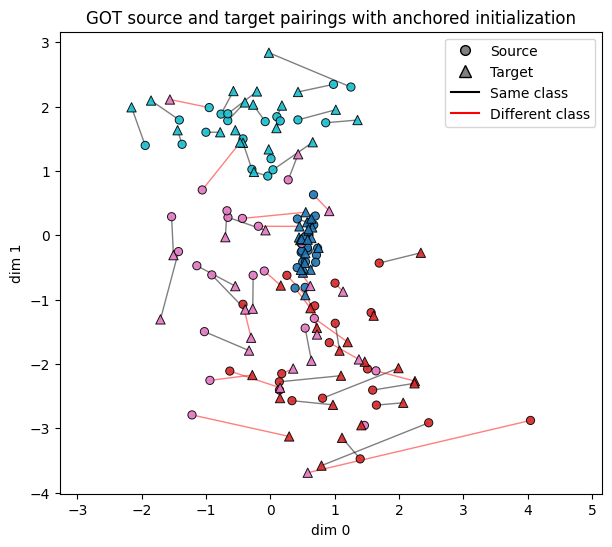

In [157]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gw_seeded, labels1, labels2)
plt.title("GOT source and target pairings with anchored initialization")

### Automated anchor selection for anchored initialization on simulated data

Does anchored initialization work if we perform PCA and anchor the most extreme outlying point of the class with the highest variance in PC1? (Answer: yes)

In [217]:
def pc1_autolabel(cloud_coords, labels, selected_class=None):
    """
    cloud_coords: (n_points, n_dims)
    labels: (n_points,) class labels (any hashable / numeric)

    Returns:
      idx: index (into original arrays) of the point in the class with the
           highest variance along PC1 that is furthest from the global PC1 mean
      info: dict with helpful diagnostics
    """
    X = np.asarray(cloud_coords, float)
    y = np.asarray(labels)
    if X.ndim != 2 or y.ndim != 1 or X.shape[0] != y.shape[0]:
        raise ValueError("cloud_coords must be (n,d) and labels must be (n,) with matching n.")

    pc1 = PCA(n_components=1).fit_transform(X).ravel()
    global_mean = pc1.mean()

    if selected_class is not None:
        best_class = selected_class
    else:
        classes = np.unique(y)
        # variance of PC1 within each class
        var_by_class = {c: np.var(pc1[y == c], ddof=1) if np.sum(y == c) > 1 else 0.0 for c in classes}
        best_class = max(var_by_class, key=var_by_class.get)

    idxs = np.where(y == best_class)[0]
    # furthest from global PC1 mean within best_class
    idx = idxs[np.argmax(np.abs(pc1[idxs] - global_mean))]

    info = {
        "best_class": best_class,
        "global_pc1_mean": float(global_mean),
        "pc1_value": float(pc1[idx]),
    }
    return int(idx), best_class


In [174]:
autolabel1, selected_class1 = pc1_autolabel(cloud_coords1, labels1)

In [175]:
autolabel2, selected_class2 = pc1_autolabel(cloud_coords2, labels2)

In [176]:
gw_autoseeded = gw_seeded(cloud_coords1, cloud_coords2, 80, [autolabel1], [autolabel2])

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


Text(0.5, 1.0, 'GOT source and target pairings with auto-anchored initialization')

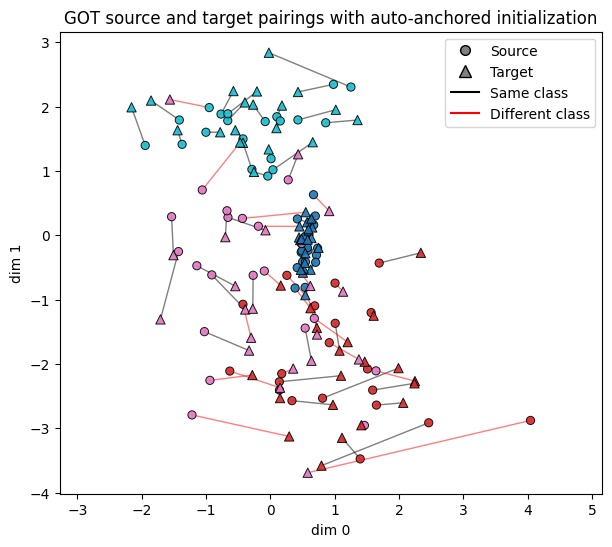

In [177]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gw_autoseeded, labels1, labels2)
plt.title("GOT source and target pairings with auto-anchored initialization")

### Auto-anchoring in higher dimensions

In [226]:
def plot_first_two_dims(
    clouds,
    alpha=0.6,
    s=10,
    annotate=False,
    text_offset=(0.01, 0.01),
    pca=False
):
    """
    clouds: array of shape (N, P, M)
    annotate: if True, write index within the flattened clouds array
    pca: if True, plot first two principal components instead of dims 0 and 1
    """
    N, P, M = clouds.shape
    global_idx = 0

    if pca:
        # Fit PCA on all points jointly
        X_all = clouds.reshape(-1, M)
        pcs = PCA(n_components=2).fit_transform(X_all)
        pcs = pcs.reshape(N, P, 2)

    for class_idx in range(N):
        if pca:
            x = pcs[class_idx, :, 0]
            y = pcs[class_idx, :, 1]
        else:
            x = clouds[class_idx, :, 0]
            y = clouds[class_idx, :, 1]

        plt.scatter(x, y, s=s, alpha=alpha)

        if annotate:
            dx, dy = text_offset
            for xi, yi in zip(x, y):
                plt.text(
                    xi + dx,
                    yi + dy,
                    str(global_idx),
                    fontsize=8,
                    alpha=alpha
                )
                global_idx += 1
        else:
            global_idx += P

    plt.xlabel("PC 1" if pca else "Dimension 1")
    plt.ylabel("PC 2" if pca else "Dimension 2")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()


In [180]:
num_clouds = 5
num_points_per_cloud = 20
num_dims = 50

In [181]:
clouds1, means1, covs1 = generate_point_clouds(num_clouds, num_points_per_cloud, num_dims, A=2, B=0.5)
cloud_coords1, labels1 = flatten_clouds(clouds1)
clouds2 = resample_point_clouds(means1, covs1, num_points_per_cloud)
cloud_coords2, labels2 = flatten_clouds(clouds2)

In [183]:
gw_unanchored_higdim = run_ot(cloud_coords1, cloud_coords2, num_clouds * num_points_per_cloud)

Text(0.5, 1.0, 'High dimensional GOT pairings without anchor')

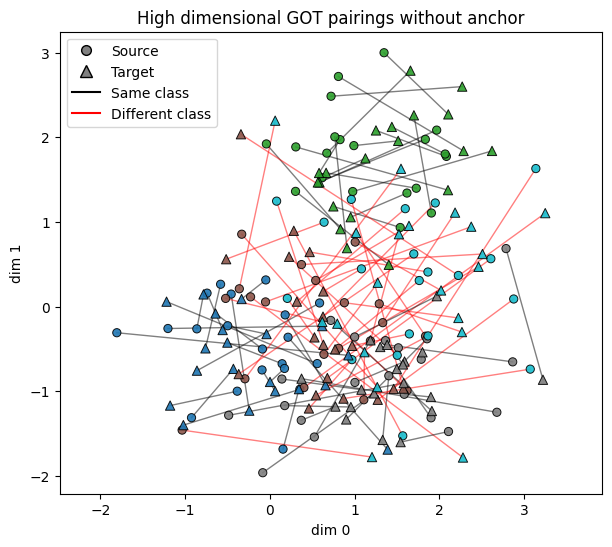

In [189]:
#acc = compute_mapping_acc(gw_unanchored_higdim, labels1, labels2)
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gw_unanchored, labels1, labels2)
plt.title("High dimensional GOT pairings without anchor") # Acc: " + 100*acc + "%")

In [218]:
autolabel1, selected_class1 = pc1_autolabel(cloud_coords1, labels1)
autolabel2, selected_class2 = pc1_autolabel(cloud_coords2, labels2, selected_class = selected_class1)

In [219]:
selected_class1

np.int64(0)

In [220]:
selected_class2

np.int64(0)

In [221]:
autolabel1, autolabel2

(8, 5)

In [229]:
gw_seeded_higdim = gw_seeded(cloud_coords1, 
                             cloud_coords2, 
                             num_clouds * num_points_per_cloud, 
                             [88], 
                             [95])

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


Text(0.5, 1.0, 'High dimensional GOT pairings with anchored initialization')

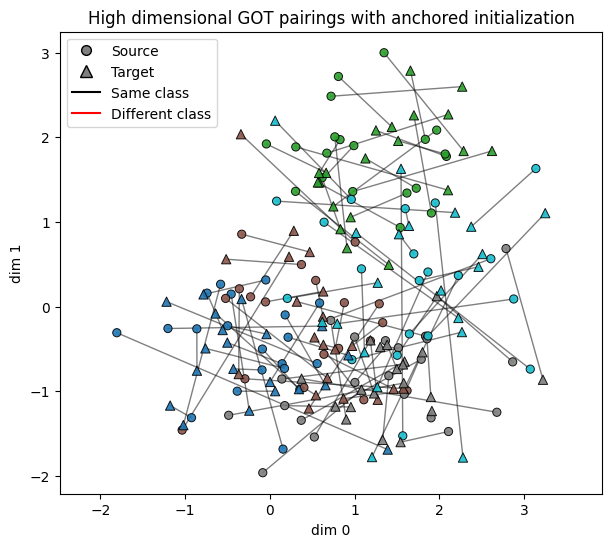

In [232]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gw_seeded_higdim, labels1, labels2)
plt.title("High dimensional GOT pairings with anchored initialization") # Acc: " + 100*acc + "%")

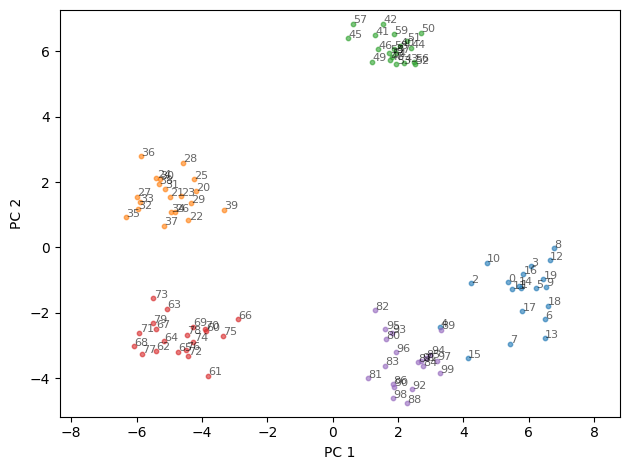

In [227]:
plot_first_two_dims(clouds1, annotate=True, pca=True)

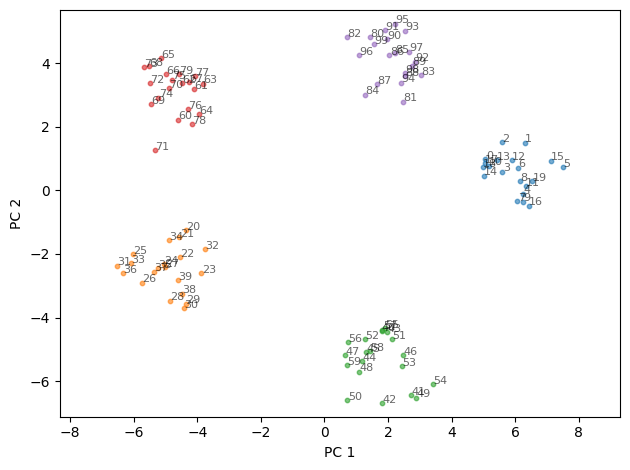

In [228]:
plot_first_two_dims(clouds2, annotate=True, pca=True)

In [ ]:
# 5 simulations with and without anchors

In [233]:
num_clouds = 5
num_points_per_cloud = 20
num_dims = 50

In [240]:
clouds1_list = []
clouds2_list = []
coords1_list = []
coords2_list = []
labels1_list = []
labels2_list = []

In [241]:
for i in range(5):
    clouds1, means1, covs1 = generate_point_clouds(num_clouds, num_points_per_cloud, num_dims, A=2, B=0.5)
    cloud_coords1, labels1 = flatten_clouds(clouds1)
    clouds2 = resample_point_clouds(means1, covs1, num_points_per_cloud)
    cloud_coords2, labels2 = flatten_clouds(clouds2)
    
    clouds1_list.append(clouds1)
    clouds2_list.append(clouds2)
    coords1_list.append(cloud_coords1)
    coords2_list.append(cloud_coords2)
    labels1_list.append(labels1)
    labels2_list.append(labels2)

0


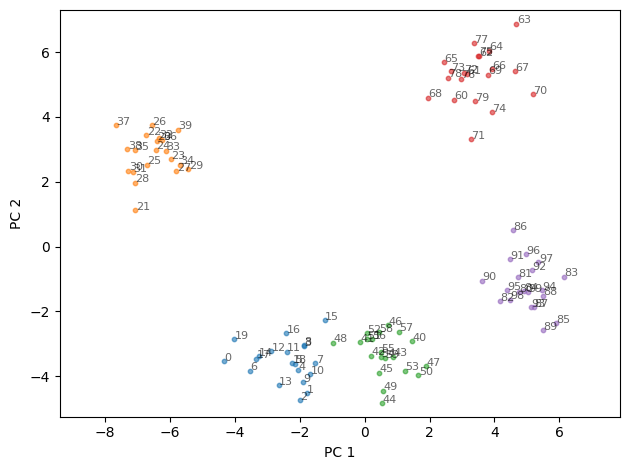

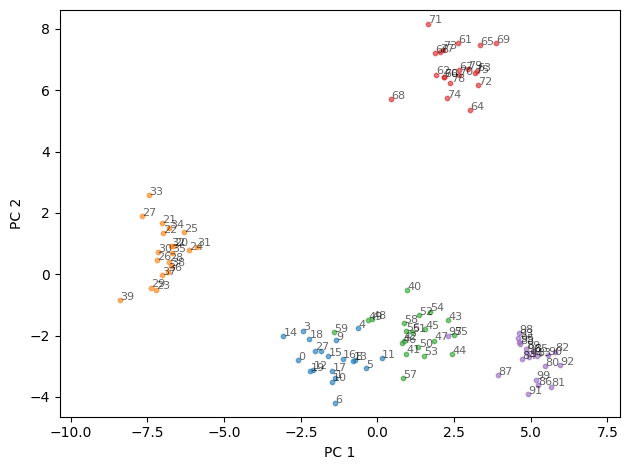

1


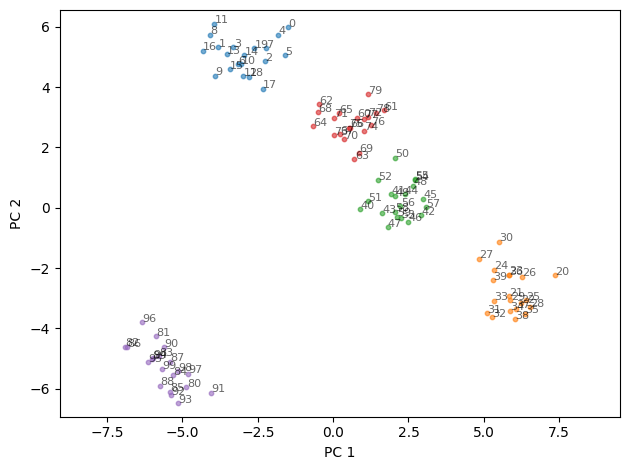

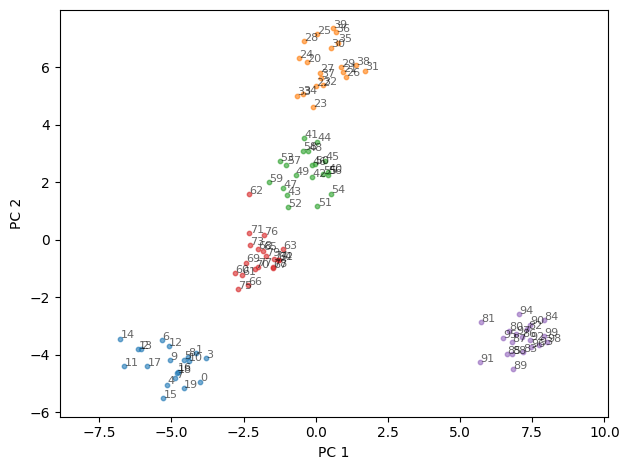

2


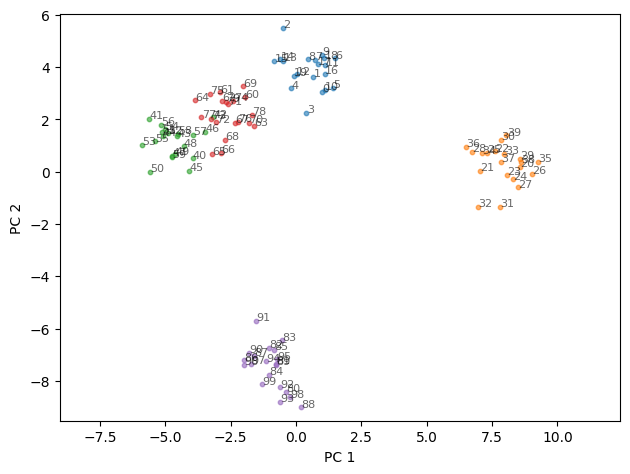

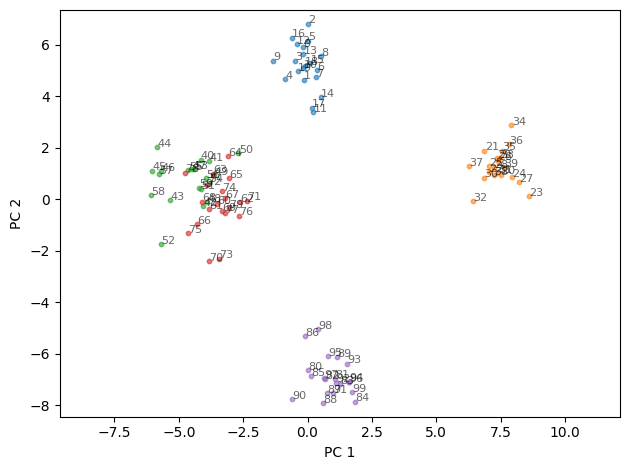

3


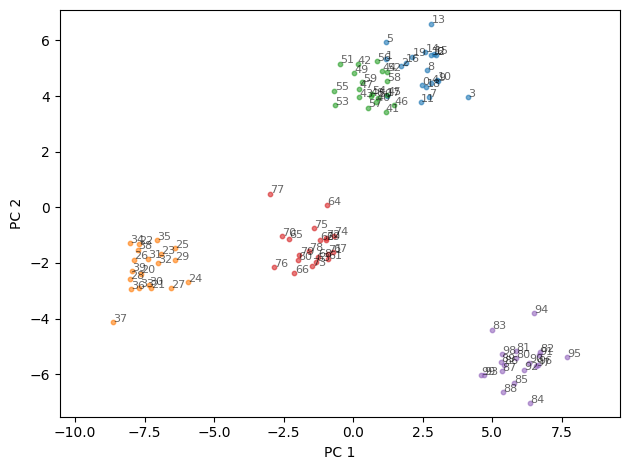

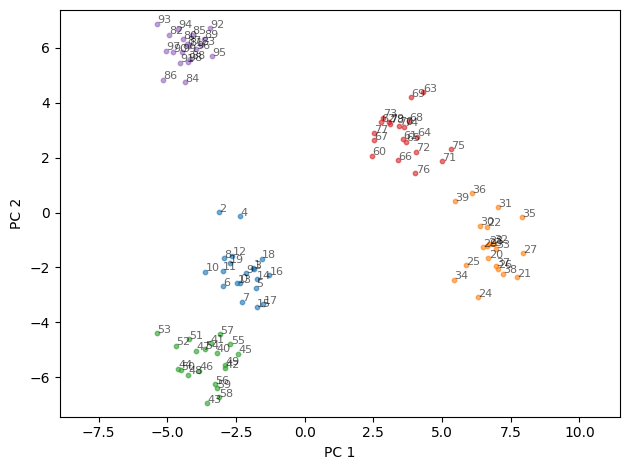

4


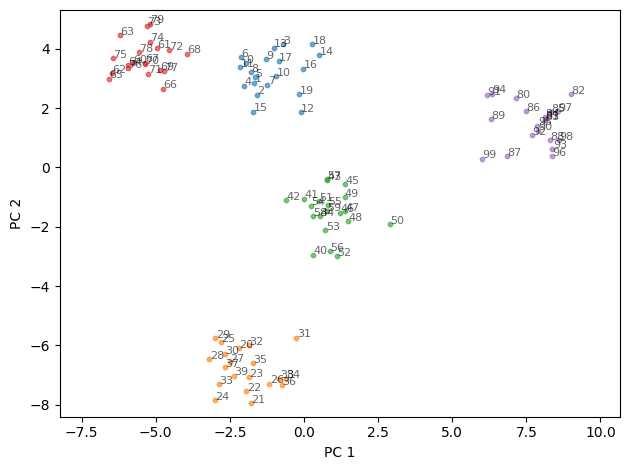

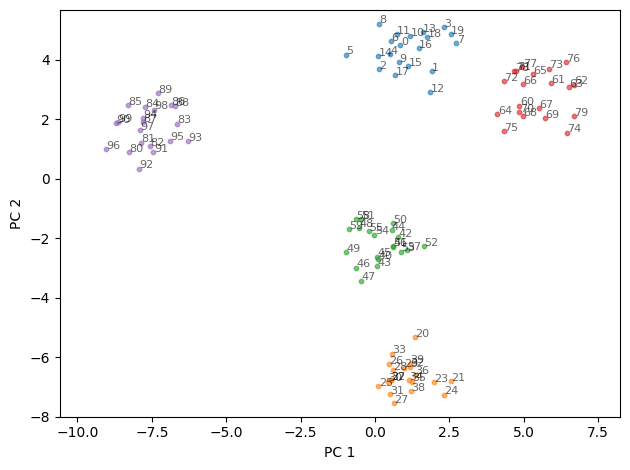

In [242]:
for i in range(5):
    print(i)
    plot_first_two_dims(clouds1_list[i], annotate=True, pca=True)
    plot_first_two_dims(clouds2_list[i], annotate=True, pca=True)

In [243]:
gw_unanchored_list = []
for i in range(5):
    gw_unanchored = run_ot(coords1_list[i], coords2_list[i], num_clouds * num_points_per_cloud)
    gw_unanchored_list.append(gw_unanchored)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [252]:
def compute_mapping_acc(transport_plan, source_labels, target_true_labels):
    """
    transport_plan: (n_source, n_target)
    source_labels: (n_source,) array-like (numpy or pandas Series)
    target_true_labels: (n_target,) array-like (numpy or pandas Series)
    """
    T = np.asarray(transport_plan)
    src = np.asarray(source_labels)          # drops pandas index
    tgt = np.asarray(target_true_labels)     # drops pandas index

    target_pred_idx = np.argmax(T, axis=1)   # length n_source
    pred_target_labels = tgt[target_pred_idx]

    return float(np.mean(src == pred_target_labels))

In [260]:
unseeded_accs = []
for i in range(5):
    unseeded_accs += [compute_mapping_acc(gw_unanchored_list[i], labels1_list[i], labels2_list[i])]

In [244]:
anchor1_list = [2, 11, 39, 34, 21]
anchor2_list = [6, 15, 34, 21, 24]

In [257]:
gw_anchored_list = []
for i in range(5):
    gw_anchored = gw_seeded(cloud_coords1, 
                             cloud_coords2, 
                             num_clouds * num_points_per_cloud, 
                             [anchor1_list[i]], 
                             [anchor2_list[i]])
    gw_anchored_list.append(gw_anchored)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [261]:
seeded_accs = []
for i in range(5):
    seeded_accs += [compute_mapping_acc(gw_anchored_list[i], labels1_list[i], labels2_list[i])]

Average 76% accuracy without anchoring, 100% accuracy with single seeded anchoring approach.

In [311]:
def plot_side_by_side_accs(seeded_accs, unseeded_accs, jitter=0.08):
    x0, x1 = 0, 1

    plt.figure(figsize=(4, 4))

    # transparent mean bars
    plt.bar(
        x1, np.mean(seeded_accs),
        width=0.4, alpha=0.25
    )
    plt.bar(
        x0, np.mean(unseeded_accs),
        width=0.4, alpha=0.25
    )

    # jittered points
    plt.scatter(
        x1 + jitter * np.random.randn(len(seeded_accs)),
        seeded_accs,
        alpha=0.7,
        s=40,
        color="gray"
    )
    plt.scatter(
        x0 + jitter * np.random.randn(len(unseeded_accs)),
        unseeded_accs,
        alpha=0.7,
        s=40,
        color="gray"
    )

    plt.xticks([x0, x1], ["Unanchored", "Anchored"])
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.1)
    plt.xlim(-0.5, 1.5)
    plt.tight_layout()
    plt.title('Accuracy improves with initialization anchor')
    plt.show()


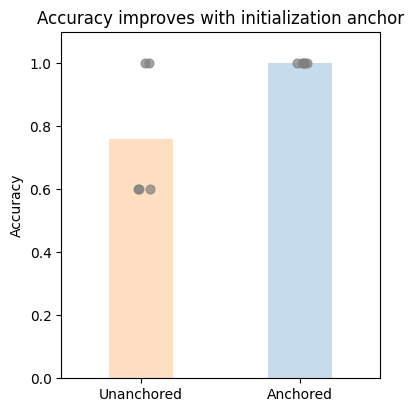

In [312]:
plot_side_by_side_accs(seeded_accs, unseeded_accs, jitter=0.04)